In [33]:
from networks import PINN_MDN
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [3]:
def mdn_loss(mu, sigma, pi, target):
    target = target.expand_as(mu)

    dist = torch.distributions.Normal(mu, sigma)
    log_prob = dist.log_prob(target)

    weighted = log_prob + torch.log(pi + 1e-8)

    log_sum = torch.logsumexp(weighted, dim=1)

    return -torch.mean(log_sum)

In [4]:
def expected_S(mu, pi):
    return torch.sum(pi * mu, dim=1, keepdim=True)

In [5]:
def pde_residual_mdn(model, t, z, k, S_max):
    t.requires_grad_(True)
    z.requires_grad_(True)

    mu, sigma, pi, v_m = model(t, z)

    S = expected_S(mu, pi)

    dS_dt = torch.autograd.grad(
        S, t,
        grad_outputs=torch.ones_like(S),
        create_graph=True
    )[0]

    dS_dz = torch.autograd.grad(
        S, z,
        grad_outputs=torch.ones_like(S),
        create_graph=True
    )[0]

    residual = dS_dt + v_m * dS_dz - k * (S_max - S)

    return residual

In [6]:
def loss_function_mdn(model,
                      t_f, z_f,
                      t_bc, z_bc, S_bc,
                      t_ic, z_ic, S_ic,
                      k, S_max):

    # PDE
    res = pde_residual_mdn(model, t_f, z_f, k, S_max)
    loss_pde = torch.mean(res**2)

    # BC
    mu_bc, sigma_bc, pi_bc, _ = model(t_bc, z_bc)
    loss_bc = mdn_loss(mu_bc, sigma_bc, pi_bc, S_bc)

    # IC
    mu_ic, sigma_ic, pi_ic, _ = model(t_ic, z_ic)
    loss_ic = mdn_loss(mu_ic, sigma_ic, pi_ic, S_ic)

    return loss_pde + loss_bc + loss_ic

In [14]:
N_bc = 1000

t_bc = torch.rand(N_bc, 1) * 1800  # время
z_bc = torch.zeros_like(t_bc)      # z = 0

# пример: константный вход
S_in_value = 50.0
S_bc = torch.ones_like(t_bc) * S_in_value

N_ic = 1000

t_ic = torch.zeros(N_ic, 1)           # t = 0
z_ic = torch.rand(N_ic, 1) * 10       # вдоль мельницы

# пример: равномерное начальное состояние
S0_value = 10.0
S_ic = torch.ones_like(z_ic) * S0_value

N_f = 10000

t_f = torch.rand(N_f, 1) * 1800
z_f = torch.rand(N_f, 1) * 10

t_bc = t_bc / 1800
z_bc = z_bc / 10

t_ic = t_ic / 1800
z_ic = z_ic / 10

t_f = t_f / 1800
z_f = z_f / 10

In [15]:
model_mdn = PINN_MDN()

optimizer = torch.optim.Adam(model_mdn.parameters(), lr=1e-3)

# параметры
k = torch.tensor(0.1)
S_max = torch.tensor(500.0)

for epoch in range(10000):

    optimizer.zero_grad()

    loss = loss_function_mdn(
        model_mdn,
        t_f, z_f,
        t_bc, z_bc, S_bc,
        t_ic, z_ic, S_ic,
        k, S_max
    )

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 3543.77099609375
Epoch 500, Loss: 9.326274871826172
Epoch 1000, Loss: 9.088165283203125
Epoch 1500, Loss: 8.832311630249023
Epoch 2000, Loss: 8.413448333740234
Epoch 2500, Loss: 7.0398783683776855
Epoch 3000, Loss: 6.85587215423584
Epoch 3500, Loss: 6.746362686157227
Epoch 4000, Loss: 6.616022109985352
Epoch 4500, Loss: 7.364297866821289
Epoch 5000, Loss: 6.3713884353637695
Epoch 5500, Loss: 6.253054141998291
Epoch 6000, Loss: 6.158633708953857
Epoch 6500, Loss: 5.9179534912109375
Epoch 7000, Loss: 5.695866107940674
Epoch 7500, Loss: 5.371065616607666
Epoch 8000, Loss: 12.591423034667969
Epoch 8500, Loss: 9.254156112670898
Epoch 9000, Loss: 3.99796199798584
Epoch 9500, Loss: 3.82218861579895


In [16]:
import torch
import numpy as np

def expected_S(mu, pi):
    return torch.sum(pi * mu, dim=1, keepdim=True)

def variance_S(mu, sigma, pi):
    return torch.sum(pi * (sigma**2 + mu**2), dim=1) - \
           torch.sum(pi * mu, dim=1)**2

In [24]:
def analytical_solution(t, z, k=0.1, S_max=500, S_in=50):
    T, Z = np.meshgrid(t, z)

    S = S_max - (S_max - S_in) * np.exp(-k * T)

    return T, Z, S

In [27]:
# сетка
t = np.linspace(0, 1, 100)
z = np.linspace(0, 1, 100)

# аналитика
_, _, S_true = analytical_solution(t, z)

In [17]:
def compute_metrics(model, t, z, S_true):

    t_tensor = torch.tensor(t.flatten(), dtype=torch.float32).reshape(-1,1)
    z_tensor = torch.tensor(z.flatten(), dtype=torch.float32).reshape(-1,1)

    S_true = torch.tensor(S_true.flatten(), dtype=torch.float32).reshape(-1,1)

    model.eval()
    with torch.no_grad():
        mu, sigma, pi, _ = model(t_tensor, z_tensor)

    S_pred = expected_S(mu, pi)

    # L2
    l2 = torch.sqrt(torch.mean((S_pred - S_true)**2))

    # MAE
    mae = torch.mean(torch.abs(S_pred - S_true))

    # NLL
    dist = torch.distributions.Normal(mu, sigma)
    log_prob = dist.log_prob(S_true.expand_as(mu))
    log_mix = torch.logsumexp(log_prob + torch.log(pi + 1e-8), dim=1)
    nll = -torch.mean(log_mix)

    return l2.item(), mae.item(), nll.item()

In [18]:
def compute_pde_residual(model, t, z, k, S_max):

    t.requires_grad_(True)
    z.requires_grad_(True)

    mu, sigma, pi, v_m = model(t, z)
    S = expected_S(mu, pi)

    dS_dt = torch.autograd.grad(S, t,
        grad_outputs=torch.ones_like(S),
        create_graph=True)[0]

    dS_dz = torch.autograd.grad(S, z,
        grad_outputs=torch.ones_like(S),
        create_graph=True)[0]

    residual = dS_dt + v_m * dS_dz - k * (S_max - S)

    return residual.detach().cpu().numpy()

In [19]:
def uncertainty_analysis(model, t, z):

    t_tensor = torch.tensor(t.flatten(), dtype=torch.float32).reshape(-1,1)
    z_tensor = torch.tensor(z.flatten(), dtype=torch.float32).reshape(-1,1)

    with torch.no_grad():
        mu, sigma, pi, _ = model(t_tensor, z_tensor)

    var = variance_S(mu, sigma, pi)

    return (
        mu.cpu().numpy(),
        sigma.cpu().numpy(),
        pi.cpu().numpy(),
        var.cpu().numpy()
    )

In [20]:
def analyze_mixture(pi):

    pi_mean = np.mean(pi, axis=0)

    print("Средние веса компонент:")
    for i, val in enumerate(pi_mean):
        print(f"Component {i}: {val:.3f}")

    dominant = np.argmax(pi_mean)

    print(f"\nДоминирующая компонента: {dominant}")

In [21]:
def full_analysis(model, t, z, S_true, k, S_max):

    T, Z = np.meshgrid(t, z)

    # Метрики
    l2, mae, nll = compute_metrics(model, T, Z, S_true)

    print("==== METRICS ====")
    print("L2:", l2)
    print("MAE:", mae)
    print("NLL:", nll)

    # PDE residual
    t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1,1)
    z_tensor = torch.tensor(Z.flatten(), dtype=torch.float32).reshape(-1,1)

    residual = compute_pde_residual(model, t_tensor, z_tensor, k, S_max)

    print("\n==== PDE ====")
    print("Residual mean:", np.mean(np.abs(residual)))

    # Uncertainty
    mu, sigma, pi, var = uncertainty_analysis(model, T, Z)

    print("\n==== UNCERTAINTY ====")
    print("Mean variance:", np.mean(var))

    analyze_mixture(pi)

    return {
        "l2": l2,
        "mae": mae,
        "nll": nll,
        "residual_mean": np.mean(np.abs(residual)),
        "variance_mean": np.mean(var)
    }

In [28]:
results = full_analysis(
    model_mdn,
    t=np.linspace(0,1,100),
    z=np.linspace(0,1,100),
    S_true=S_true,   # аналитика или FDM
    k=0.1,
    S_max=500
)

==== METRICS ====
L2: 64.0877685546875
MAE: 62.85857009887695
NLL: 21.313995361328125

==== PDE ====
Residual mean: 0.10916159

==== UNCERTAINTY ====
Mean variance: 55.18568
Средние веса компонент:
Component 0: 0.083
Component 1: 0.779
Component 2: 0.138

Доминирующая компонента: 1


In [29]:
# сетка
t = np.linspace(0, 1, 100)
z = np.linspace(0, 1, 100)

T, Z = np.meshgrid(t, z)

t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1,1)
z_tensor = torch.tensor(Z.flatten(), dtype=torch.float32).reshape(-1,1)

model_mdn.eval()
with torch.no_grad():
    mu, sigma, pi, v = model_mdn(t_tensor, z_tensor)

# reshape
mu = mu.reshape(100, 100, -1).cpu().numpy()
sigma = sigma.reshape(100, 100, -1).cpu().numpy()
pi = pi.reshape(100, 100, -1).cpu().numpy()

S_mean = np.sum(pi * mu, axis=2)
S_var = np.sum(pi * (sigma**2 + mu**2), axis=2) - S_mean**2

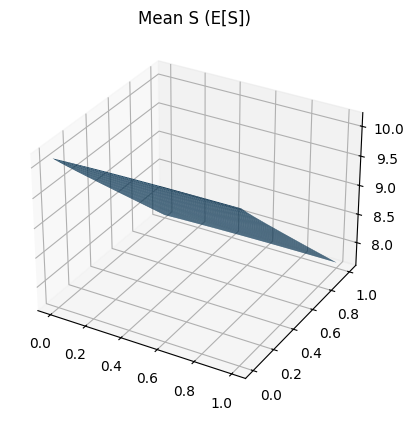

In [34]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, S_mean)
ax.set_title("Mean S (E[S])")
plt.show()

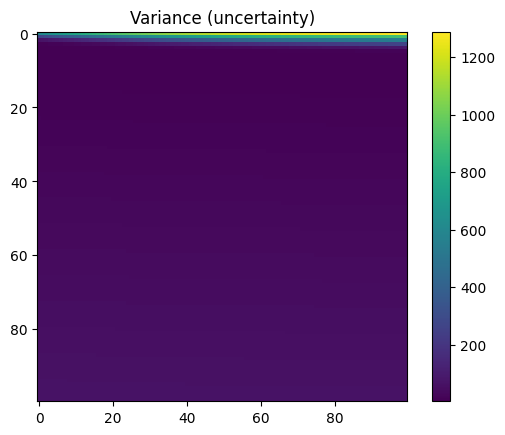

In [35]:
plt.figure()
plt.imshow(S_var)
plt.title("Variance (uncertainty)")
plt.colorbar()
plt.show()

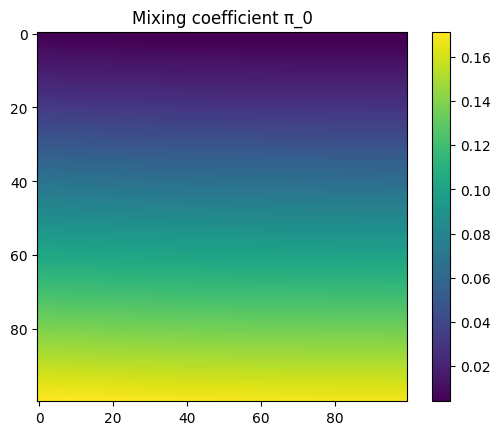

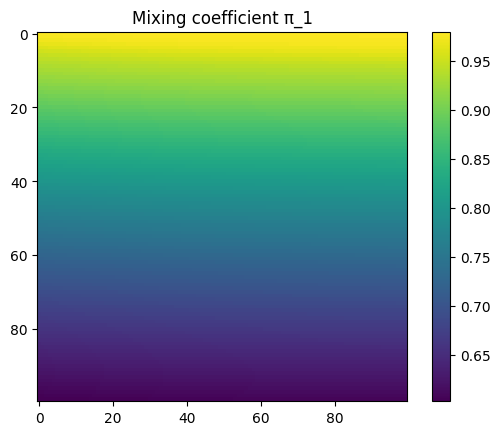

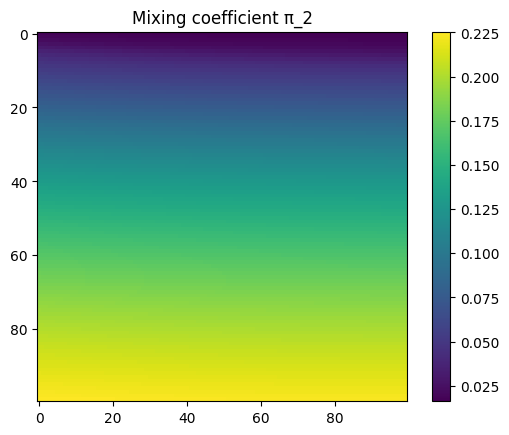

In [36]:
n_components = pi.shape[2]

for k in range(n_components):
    plt.figure()
    plt.imshow(pi[:, :, k])
    plt.title(f"Mixing coefficient π_{k}")
    plt.colorbar()
    plt.show()

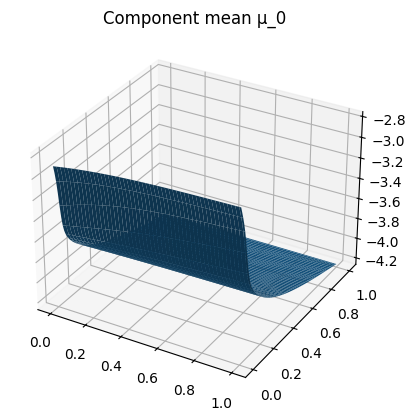

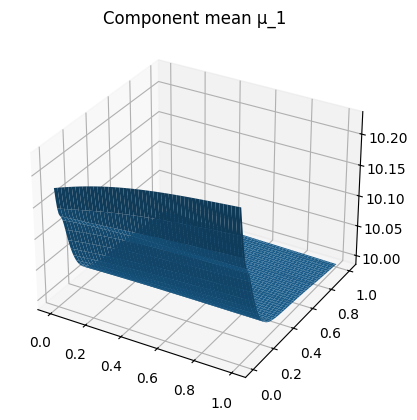

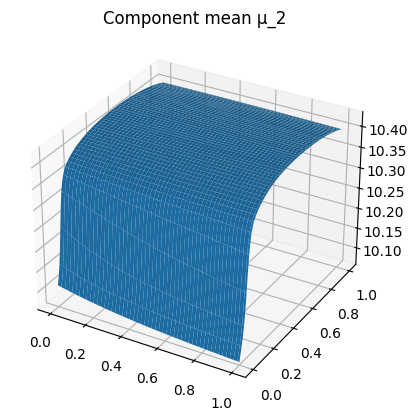

In [37]:
for k in range(n_components):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(T, Z, mu[:, :, k])
    ax.set_title(f"Component mean μ_{k}")
    plt.show()

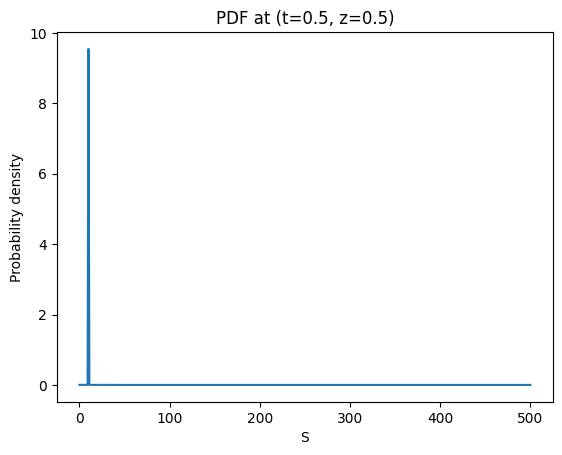

In [38]:
# выбираем точку
i, j = 50, 50

mu_point = mu[i, j, :]
sigma_point = sigma[i, j, :]
pi_point = pi[i, j, :]

x = np.linspace(0, 500, 500)
pdf = np.zeros_like(x)

for k in range(len(pi_point)):
    pdf += pi_point[k] * (
        1 / (sigma_point[k] * np.sqrt(2*np.pi)) *
        np.exp(-(x - mu_point[k])**2 / (2 * sigma_point[k]**2))
    )

plt.figure()
plt.plot(x, pdf)
plt.title("PDF at (t=0.5, z=0.5)")
plt.xlabel("S")
plt.ylabel("Probability density")
plt.show()

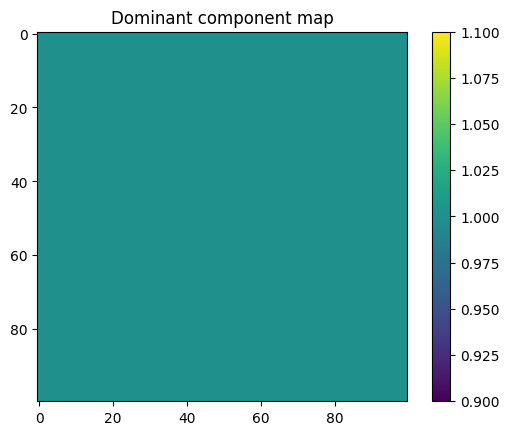

In [39]:
dominant = np.argmax(pi, axis=2)

plt.figure()
plt.imshow(dominant)
plt.title("Dominant component map")
plt.colorbar()
plt.show()